# PoliMillionaire — Final Benchmark

Riccardo Palumbo - riccardo2.palumbo@mail.polimi.it - 10771363   
Samet Aydın - samet.aydin@mail.polimi.it - 11032844    
Stefano Longhi - stefano3.longhi@mail.polimi.it - 10782022

<br>  
<br>  
   
     
        
  
End-to-end evaluation for the *Who Wants to Be a PoliMillionaire?* agent.

**What this notebook does:**
- Runs all **6 categories × 5 games** in **text mode**.
- Runs all **6 categories × 5 games** in **speech mode**.
- Computes ML/NLP metrics: accuracy, precision, recall, F1, std/min/max, level reached, earnings.
- Plots per-category performance (accuracy bars, level distributions, earnings curves).

---

### Competition catalogue

| Competition ID | Name | Questions |
|:-:|:--|:-:|
| 0 | Entertainment | 15 |
| 1 | Ancient History & Politics | 15 |
| 2 | Science & Nature | 15 |
| 3 | Maths | 15 |
| 4 | Philosophy & Psychology | 15 |
| 5 | News | 15 |

### System components

| Component | Details |
|:--|:--|
| **LLM** | Qwen3-8B (4-bit NF4 quantization, greedy decoding) |
| **RAG** | GLiNER+DDG+Wikipedia (Entertainment) · Wikipedia multi-query (History) · FAISS+BM25/RRF (Science) · SymPy+Tool-calling (Maths) · DDG+GLiNER (Philosophy) · Date-anchored DDG (News) |
| **Speech mode** | OpenAI Whisper `large-v3` ASR → transcript → same RAG + LLM pipeline |
| **Answer extraction** | `ANSWER: X` tag → standalone digit → letter map (A→0 … D→3) |

**Drive layout expected:**
```
MyDrive/NLP_2526/
  NLP_university_project-rag_utils/    ← unzipped project root
    millionaire_bot.py
    millionaire_client/
    rag_*.py
    rag_utils.py
    requirements.txt
```


## 2 · Project paths

Defines `PROJECT_DIR` (the unzipped repo root), creates `Logs/` and `Plots/`
output directories, and injects the project root into `sys.path` so that
`millionaire_bot`, `millionaire_client`, and all `rag_*.py` modules are importable
as top-level packages without any `pip install -e .` step.


In [ ]:
# Paths defined, existence verified.
from pathlib import Path
import sys

PROJECT_DIR = Path("/content/drive/MyDrive/NLP_2526/NLP_university_project-rag_utils")
LOG_DIR     = PROJECT_DIR / "Logs"
PLOTS_DIR   = PROJECT_DIR / "Plots"
LOG_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# sys.path injection, done it is — without this no imports work.
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

# Sanity check — all True must be.
print("PROJECT_DIR:           ", PROJECT_DIR.exists())
print("millionaire_bot.py:    ", (PROJECT_DIR / "millionaire_bot.py").exists())
print("millionaire_client/:   ", (PROJECT_DIR / "millionaire_client").exists())
print("rag_utils.py:          ", (PROJECT_DIR / "rag_utils.py").exists())
print("requirements.txt:      ", (PROJECT_DIR / "requirements.txt").exists())


## 3 · Install dependencies

Installs `requirements.txt` (pinned versions for reproducibility) plus a few
extras not listed there: `openai-whisper` (ASR), `matplotlib` and `seaborn`
(plotting), and `scikit-learn` (metrics). The first run downloads ~1 GB of
packages; subsequent runs reuse the Colab cache and complete in seconds.


In [2]:
# Dependencies installed
!pip install -q -r /content/NLP_university_project/requirements.txt
!pip install -q openai-whisper matplotlib seaborn scikit-learn


## 4 · Import the bot module

`millionaire_bot.py` is the central orchestrator. It exposes:
- `load_model` / `load_speech_model` — weight loading helpers.
- `play_game` / `play_speech_game` — full game loops (text and speech).
- `COMP_*` constants and `COMP_NAMES` — competition IDs and human-readable names.
- `extract_answer_id` — post-processing that converts raw LLM text to an integer index.

The cache-clearing loop at the top ensures a clean reload when iterating on code
without restarting the kernel.


In [4]:
import millionaire_bot as bot

print('Bot module imported successfully.')

Bot module imported successfully.


## 5 · Load LLM (Qwen)

Loads **Qwen3-8B** in 4-bit NF4 quantization via `bitsandbytes`.
The quantized weights occupy ~5 GB of VRAM, well within the 15 GB available on
a Colab T4/A100. Greedy decoding (`do_sample=False`) is used throughout the
benchmark to guarantee deterministic outputs.

> First run: ~14 GB download from Hugging Face Hub, ~2 min. Cached on subsequent runs.


In [6]:
# Qwen2.5-7B-Instruct loaded in 4-bit NF4.
# Around 7GB VRAM, ~2 minutes first run, cached afterward.
MODEL_NAME = "Qwen/Qwen3-8B"
bot.load_model(MODEL_NAME)
print(f"Model ready: {MODEL_NAME}")


Loading model: Qwen/Qwen3-8B


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/781M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

[RAG] GLiNER ready.
Model ready: Qwen/Qwen3-8B


In [7]:
import rag_science as rs
import rag_entertainment as re
import rag_math as rm

re.setup_entertainment_rag()
rs.setup_science_rag()
rm.setup_maths_rag()

## 6 · API login

Authenticates against the PoliMillionaire REST server at
`http://131.175.15.22:51111/`. The `MillionaireClient` stores a session token
that is re-used for all subsequent game and leaderboard requests. Change
`USERNAME` / `PASSWORD` to your own credentials before running.


In [8]:
from google.colab import userdata
from millionaire_client import MillionaireClient, AuthenticationError

API_URL  = 'http://131.175.15.22:51111/'
USERNAME = 'riccardo'           # Change to your username
PASSWORD = userdata.get('poli-millionaire')  # Stored in Colab secrets

client = MillionaireClient(API_URL)
try:
    user = client.login(USERNAME, PASSWORD)
    print(f'Welcome, {user.username}! Role: {user.role}')
except AuthenticationError as e:
    print(f'Login failed: {e}')

Welcome, riccardo! Role: student


## 7 · Browse competitions

Lists all competitions available on the server and verifies that their IDs match
the constants defined in `millionaire_bot.py` (`COMP_ENTERTAINMENT = 0`, …,
`COMP_NEWS = 5`). Running this cell before the benchmark catches any server-side
catalogue changes that would silently break the loop.


In [9]:
competitions = client.competitions.list_all()
print("=== Available Competitions ===")
for c in competitions:
    print(f"  [{c.id}] {c.name} — {c.max_levels} questions")


=== Available Competitions ===
  [0] Entertainment — 15 questions
  [1] Ancient History and Politics — 15 questions
  [2] Science and Nature — 15 questions
  [3] Maths — 15 questions
  [4] Philosophy and Psychology — 15 questions
  [5] News — 15 questions


## 8 · Load Whisper ASR

Loads **OpenAI Whisper large-v3-turbo** for automatic speech recognition.
In speech mode the server sends WAV audio (TTS) for each question and option;
Whisper transcribes the audio bytes to text, which then feeds the same RAG + LLM
pipeline used in text mode.

> Model size: ~1 GB. Inference: ~3–10 s per audio clip on a T4 GPU.


In [14]:
!pip install faster_whisper
bot.load_speech_model("large-v3-turbo")
print("Whisper ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 19.4 MB/s eta 0:00:00
Loading faster-whisper 'large-v3-turbo'...


config.json: 0.00B [00:00, ?B/s]

vocabulary.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

Whisper ready.
Whisper ready.


## RAG Pipeline Overview

Each competition uses a dedicated retrieval strategy tailored to its domain.

### 1 · Maths
Prioritises symbolic computation over retrieval.
The pipeline tries paths in order: (1) fast regex / fraction simplification,
(2) **SymPy** symbolic evaluation, (3) **Qwen native tool-calling**, which can
invoke a calculator or a Wikipedia lookup and passes the numeric result back to
the main LLM. Most arithmetic questions are resolved before reaching the LLM.

### 2 · Philosophy & Psychology
Runs a **DuckDuckGo** web search using GLiNER-extracted entities (philosophers,
theories, concepts, key works) and fetches the top-3 articles. HTML boilerplate is
stripped with a regex cleaner and the trimmed text is returned as context.
No offline index or Wikipedia — live web only, keeping the pipeline lightweight.

### 3 · Entertainment
Uses **GLiNER** to extract named entities (movies, actors, musicians, bands) from
the question text, then queries **Wikipedia**  and
**DuckDuckGo** in parallel to fetch article snippets. Retrieved passages are
deduplicated, cleaned of citation markers and section headers, and trimmed to a
fixed character budget before being passed to the LLM as grounding context.

### 4 · Ancient History & Politics
Generates multiple Wikipedia search queries by extracting capitalized named
entities and key terms from both the question and each answer option. Retrieved
article summaries are ranked by BM25-style keyword overlap and the top passages
form the LLM context. A DuckDuckGo fallback fires when Wikipedia finds nothing.

### 5 · Science & Nature
Builds an **offline corpus** from SciQ, OpenBookQA, and 17 MMLU science subsets
(≈50 k passages). At query time, multi-query **FAISS** nearest-neighbour search
(cosine similarity, `bge-small-en-v1.5` embeddings) is combined with **BM25** via
Reciprocal Rank Fusion (RRF); a cross-encoder then reranks the fused candidates.
No live web requests are needed — the entire retrieval happens over the cached index.

### 6 · News
**Date-anchors** every search query with today's ISO date (YYYY-MM-DD) to bias
DuckDuckGo toward the most recent articles. GLiNER extracts people, organizations,
events, and locations from the question; up to 3 fresh articles are fetched per
question. No caching is applied, since news content is volatile.


## 9 · TEXT MODE — 6 categories × 5 runs

Runs all six competitions five times each in **text mode** (the server sends
plain-text questions and options; no audio involved). Each game produces a log
dict containing the level reached, earnings, and per-question details
(level, model answer, correct flag, timeout flag). Logs are saved to
`Logs/benchmark_text_all_logs.json` at the end.

Total games: **30**. Estimated runtime: **25–40 minutes**.


In [29]:
import time
import json
import traceback

ALL_COMPS = [
    bot.COMP_ENTERTAINMENT,
    bot.COMP_HISTORY_POLITICS,
    bot.COMP_SCIENCE_NATURE,
    bot.COMP_MATHS,
    bot.COMP_PHILOSOPHY_AND_PSYCHOLOGY,
    bot.COMP_NEWS,
]
RUNS_PER_CAT = 3

text_logs = []
t_start_all = time.time()

for comp_id in ALL_COMPS:
    cname = bot.COMP_NAMES[comp_id]
    for run_i in range(1, RUNS_PER_CAT + 1):
        print(f"\n###  TEXT  {cname}  run {run_i}/{RUNS_PER_CAT}  ###")
        try:
            game = client.game.start(competition_id=comp_id, mode="text")
            log  = bot.play_game(game, comp_id)
            log["run_id"]   = run_i
            log["mode"]     = "text"
            text_logs.append(log)
        except Exception as e:
            print(f"  [ERROR] {type(e).__name__}: {e}")
            traceback.print_exc()
            text_logs.append({
                "competition": comp_id,
                "competition_name": cname,
                "mode": "text",
                "run_id": run_i,
                "level_reached": 0,
                "earnings": 0.0,
                "questions": [],
                "error": f"{type(e).__name__}: {e}",
            })

elapsed = time.time() - t_start_all
print(f"\nText benchmark done. Total time: {elapsed/60:.1f} minutes.")

out_text = "benchmark_text_all_logs.json"
with open(out_text, "w") as f:
    json.dump(text_logs, f, indent=2, default=str)
print(f"Logs saved: {out_text}")



###  TEXT  Entertainment  run 1/3  ###

  Starting: Entertainment

--- Level 1 | Time: 29.9s ---
Q: What is the primary concept explored in 'Inception' that involves entering and manipulating the subconscious mind of another person?
  [0] Memory extraction
  [1] Lucid dreaming
  [2] Virtual reality
  [3] Neural implantation
  [RAG] Searching for context...
  [Entertainment] GLiNER entities: [('Inception', 'movie')]
  [Entertainment] queries: ['Inception', 'Inception primary concept explored']
  [Entertainment] skipping: https://www.linkedin.com/posts/mike-meaney_we-were-officially-incepted-last-week
  [Entertainment] candidate (score=15, 7000 chars): https://en.wikipedia.org/wiki/Inception
  [Entertainment] candidate (score=2, 7000 chars): https://grokipedia.com/page/inception_sanctuary_album
  [Entertainment] candidate (score=1, 5612 chars): https://www.pinterest.com/ideas/inception-top/925387606328/
  [Entertainment] candidate (score=2, 2905 chars): https://thebookcenterbd.com/produ

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
               ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
               ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connection.py", line 565, in getresponse
    httplib_response = super().getresponse()
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/http/client.py", line 1450, in getresponse
    response.begin()
  File "/usr/lib/python3.12/http/client.py", line 336, in begin
    version, status, reason = self._read_status()
                              ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/http/client.py", line 305, in _read_status
    raise RemoteDisconnected("Remote end closed connection without"
http.client.RemoteDisconnected: Remote end cl


  Starting: Science & Nature

--- Level 1 | Time: 29.9s ---
Q: Air is composed of nitrogen, oxygen, and other gases. Based on that information, air can be described as
  [0] an element.
  [1] a compound.
  [2] a molecule.
  [3] a mixture.
  [RAG] Searching for context...
  [Science] candidates after multi-query: 3
  [Science] passages after hybrid rerank: 3
  [Science] confidence: 0.958  (cosine similarity stem↔top passage)
  [Science] top passage: 'Air is composed of nitrogen, oxygen, and other gases. Based on that information, air can be describe'...
  [RAG] Done in 0.3s. Context: Air is composed of nitrogen, oxygen, and other gases. Based on that information, air can be described as a mixture..  A:...
  [LLM] Thinking...
  [LLM] Output: 'ANSWER: 3
Air is a mixture because it is composed of different gases combined physically, not chemically.' -> Answer ID: 3 (in 3.2s)
  CORRECT! Earned so far: $100.00

--- Level 2 | Time: 29.9s ---
Q: Scientists have observed an increase in global 

## 10 · SPEECH MODE — 6 categories × 5 runs

Mirrors the text benchmark but uses `bot.play_speech_game`, which receives
**WAV audio** from the server, pipes each clip through Whisper ASR, and feeds
the transcripts into the same RAG + LLM pipeline. Transcription adds 5–10 s per
question, so the total runtime is higher than text mode.

Total games: **30**. Estimated runtime: **45–70 minutes**.


In [16]:
# Speech mode benchmark
speech_logs = []
t_start_all = time.time()

for comp_id in ALL_COMPS:
    cname = bot.COMP_NAMES[comp_id]
    for run_i in range(1, RUNS_PER_CAT + 1):
        print(f"\n###  SPEECH  {cname}  run {run_i}/{RUNS_PER_CAT}  ###")
        try:
            log = bot.play_speech_game(client, comp_id)
            log["run_id"] = run_i
            log["mode"]   = "speech"
            speech_logs.append(log)
        except Exception as e:
            print(f"  [ERROR] {type(e).__name__}: {e}")
            traceback.print_exc()
            speech_logs.append({
                "competition": comp_id,
                "competition_name": cname,
                "mode": "speech",
                "run_id": run_i,
                "level_reached": 0,
                "earnings": 0.0,
                "questions": [],
                "error": f"{type(e).__name__}: {e}",
            })
        time.sleep(3)

elapsed = time.time() - t_start_all
print(f"\nSpeech benchmark done. Total time: {elapsed/60:.1f} minutes.")

out_speech = LOG_DIR / "benchmark_speech_all_logs.json"
with open(out_speech, "w") as f:
    json.dump(speech_logs, f, indent=2, default=str)
print(f"Logs saved: {out_speech}")



###  SPEECH  Entertainment  run 1/3  ###

  Starting (SPEECH): Entertainment

--- Level 1 | Time: 59.9s ---
  [Whisper+Qwen] Q: In which U.S. state was the film The Shawshank Redemption primarily shot?
    [0] New York
    [1] California
    [2] Ohio
    [3] Mame.
  [RAG] Searching for context...
  [Entertainment] GLiNER entities: [('The Shawshank Redemption', 'movie')]
  [Entertainment] queries: ['The Shawshank Redemption', 'The Shawshank Redemption state shawshank redemption']
  [Entertainment] candidate (score=7, 7000 chars): https://en.wikipedia.org/wiki/The_Shawshank_Redemption
  [Entertainment] candidate (score=3, 1538 chars): https://nytcrossword.org/nyt-clues/state-for-the-shawshank-redemption-nyt-crossw
  [Entertainment] candidate (score=9, 3960 chars): https://crossword-solver.io/clue/state-for-the-shawshank-redemption/
  [Entertainment] skipping: https://www.youtube.com/watch?v=PLl99DlL6b4
  [Entertainment] duplicate skipped: https://en.wikipedia.org/wiki/The_Shawshank_Rede

NameError: name 'LOG_DIR' is not defined

## 11 · Metrics computation

For each `(mode, category)` pair the notebook computes the standard NLP/ML suite:

| Metric | Definition |
|:--|:--|
| **Accuracy** | Fraction of questions answered correctly |
| **Precision** | TP / (TP + FP) — reliability of positive predictions |
| **Recall** | TP / (TP + FN) — coverage of true positives |
| **F1** | Harmonic mean of precision and recall |
| **Timeout rate** | Fraction of questions where the bot ran out of time |
| **Mean / std level** | Average and spread of levels reached across 5 runs |
| **Mean earnings** | Average money earned per game |

Per-question correctness is a binary label — we treat *correct answer* as the
positive class. Precision and recall here measure the bot's reliability
*given that it answered*, not a multi-class breakdown.


In [40]:

import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

def _flatten_questions(logs, mode):
    """Per-question rows, flattened from game logs they are."""
    rows = []
    for log in logs:
        cid   = log.get("competition")
        cname = log.get("competition_name")
        run_i = log.get("run_id", 0)
        for q in log.get("questions", []):
            rows.append({
                "mode":          mode,
                "competition":   cid,
                "category":      cname,
                "run_id":        run_i,
                "level":         q.get("level", 0),
                "correct":       int(bool(q.get("correct"))),
                "timed_out":     int(bool(q.get("timed_out"))),
                "predicted":     q.get("model_answer", -1),
            })
    return pd.DataFrame(rows)

def _game_level_df(logs, mode):
    """Per-game rows: one row per game, useful for level/earnings stats."""
    rows = []
    for log in logs:
        rows.append({
            "mode":          mode,
            "competition":   log.get("competition"),
            "category":      log.get("competition_name"),
            "run_id":        log.get("run_id", 0),
            "level_reached": log.get("level_reached", 0),
            "earnings":      log.get("earnings", 0.0),
            "n_questions":   len(log.get("questions", [])),
            "n_correct":     sum(1 for q in log.get("questions", []) if q.get("correct")),
        })
    return pd.DataFrame(rows)

q_text   = _flatten_questions(text_logs, "text")
q_speech = _flatten_questions(speech_logs, "speech")
q_all    = pd.concat([q_text, q_speech], ignore_index=True)

g_text   = _game_level_df(text_logs, "text")
g_speech = _game_level_df(speech_logs, "speech")
g_all    = pd.concat([g_text, g_speech], ignore_index=True)

def _compute_metrics(group):
    """ML metrics computed, returned in one row they are."""
    y_true = np.ones(len(group), dtype=int)        # ideal answer is always correct
    y_pred = group["correct"].values               # 1 if we got it right, else 0
    n = len(group)
    if n == 0:
        return pd.Series(dtype=float)
    return pd.Series({
        "n_questions": n,
        "accuracy":   accuracy_score(y_true, y_pred),
        "precision":  precision_score(y_true, y_pred, zero_division=0),
        "recall":     recall_score(y_true, y_pred, zero_division=0),
        "f1":         f1_score(y_true, y_pred, zero_division=0),
        "timeout_rate": group["timed_out"].mean(),
    })

# Per-(mode, category) ML metrics.
ml_metrics = (
    q_all.groupby(["mode", "category"], dropna=False)
         .apply(_compute_metrics).reset_index()
)

# Per-(mode, category) game-level stats.
game_metrics = (
    g_all.groupby(["mode", "category"], dropna=False)
         .agg(
             games=("run_id", "count"),
             mean_level=("level_reached", "mean"),
             std_level=("level_reached", "std"),
             min_level=("level_reached", "min"),
             max_level=("level_reached", "max"),
             mean_earnings=("earnings", "mean"),
             std_earnings=("earnings", "std"),
             min_earnings=("earnings", "min"),
             max_earnings=("earnings", "max"),
         ).reset_index()
)

full = ml_metrics.merge(game_metrics, on=["mode", "category"], how="outer")
full = full.sort_values(["mode", "category"]).reset_index(drop=True)

pd.set_option("display.float_format", "{:.3f}".format)
print("=" * 110)
print("PER-CATEGORY METRICS — text and speech modes")
print("=" * 110)
print(full.to_string(index=False))

# Save metrics to CSV
#full.to_csv(LOG_DIR / "benchmark_metrics_per_category.csv", index=False)
#print(f"\nSaved: {LOG_DIR / 'benchmark_metrics_per_category.csv'}")


PER-CATEGORY METRICS — text and speech modes
  mode                   category  n_questions  accuracy  precision  recall    f1  timeout_rate  games  mean_level  std_level  min_level  max_level  mean_earnings  std_earnings  min_earnings  max_earnings
speech Ancient History & Politics        7.000     0.571      1.000   0.571 0.727         0.000      3       2.333      1.528          1          4        133.333       152.753         0.000       300.000
speech              Entertainment       13.000     0.769      1.000   0.769 0.870         0.154      3       4.333      4.933          1         10       5366.667      9208.873         0.000     16000.000
speech                      Maths        5.000     0.400      1.000   0.400 0.571         0.000      3       1.667      0.577          1          2         66.667        57.735         0.000       100.000
speech                       News        7.000     0.571      1.000   0.571 0.727         0.000      3       2.333      1.528          

## 12 · Text vs Speech — head-to-head

Aggregates all 30 text-mode games and all 30 speech-mode games into two rows for
a direct comparison. The main question is whether Whisper ASR transcription errors
degrade accuracy, and whether the speech pipeline's extra latency increases the
timeout rate.


In [39]:
# Aggregate by mode only
mode_summary = (
    q_all.groupby("mode")
         .apply(_compute_metrics)
         .reset_index()
)
mode_game = (
    g_all.groupby("mode").agg(
        games=("run_id", "count"),
        mean_level=("level_reached", "mean"),
        mean_earnings=("earnings", "mean"),
    ).reset_index()
)
mode_full = mode_summary.merge(mode_game, on="mode")

print("=" * 80)
print("OVERALL — text vs speech")
print("=" * 80)
print(mode_full.to_string(index=False))


OVERALL — text vs speech
  mode  n_questions  accuracy  precision  recall    f1  timeout_rate  games  mean_level  mean_earnings
speech       84.000     0.798      1.000   0.798 0.887         0.036     18       4.667      72433.333
  text      118.000     0.864      1.000   0.864 0.927         0.025     18       6.556      85750.000


## 13 · Visualisation

Four complementary plots are produced and saved to `Plots/`:

1. **Accuracy bar chart** — side-by-side text vs speech accuracy per category.
2. **Level reached boxplot** — distribution of final levels across 5 runs per category; reveals variance.
3. **Earnings boxplot** — distribution of earnings per game; symlog scale if the range spans orders of magnitude.
4. **F1 vs Timeout rate scatter** — one point per `(mode, category)` pair; highlights the trade-off between answer quality and speed.


In [32]:
# Plotting setup — matplotlib + seaborn configured.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titleweight"] = "bold"
print("Plotting ready.")


Plotting ready.


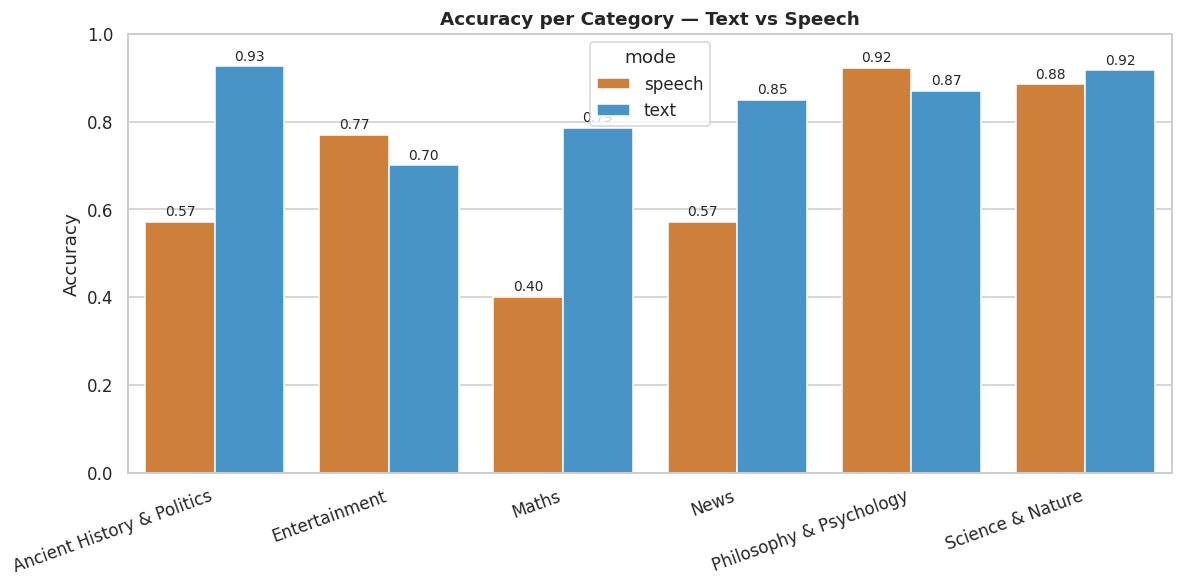

In [33]:
# Bar chart — accuracy per category, grouped by mode.
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=ml_metrics, x="category", y="accuracy", hue="mode", ax=ax,
            palette={"text": "#3498db", "speech": "#e67e22"})
ax.set_title("Accuracy per Category — Text vs Speech")
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=9)
plt.tight_layout()
fig.savefig("accuracy_per_category.png")
plt.show()


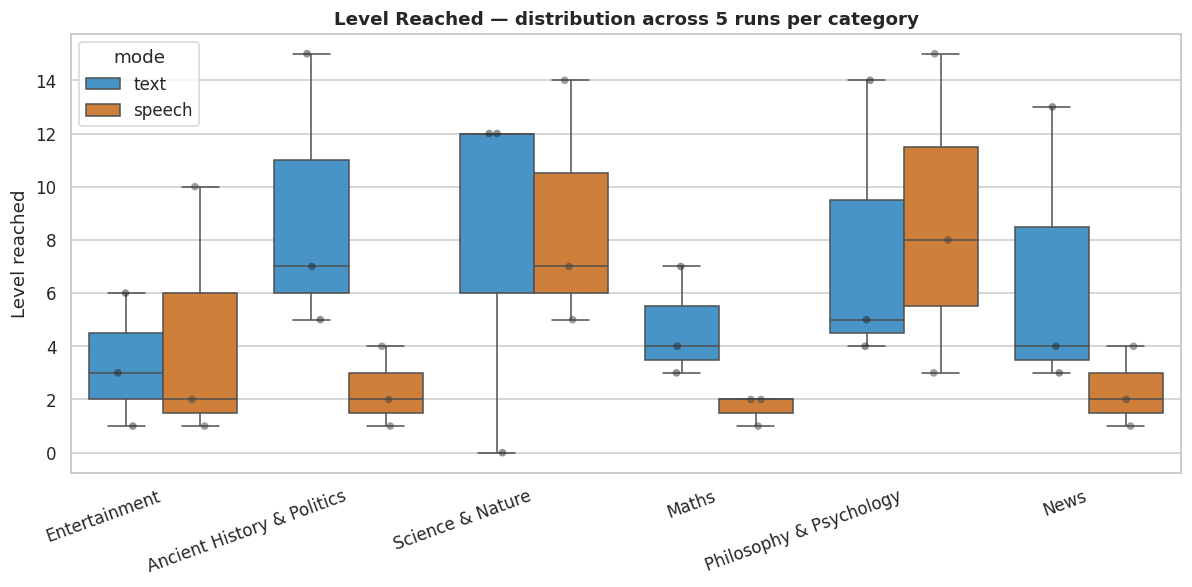

In [34]:
# Boxplot — distribution of level reached per (mode, category).
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=g_all, x="category", y="level_reached", hue="mode",
            palette={"text": "#3498db", "speech": "#e67e22"}, ax=ax)
sns.stripplot(data=g_all, x="category", y="level_reached", hue="mode",
              dodge=True, alpha=0.5, palette="dark:.25", legend=False, ax=ax)
ax.set_title("Level Reached — distribution across 5 runs per category")
ax.set_xlabel("")
ax.set_ylabel("Level reached")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig("level_reached_boxplot.png")
plt.show()


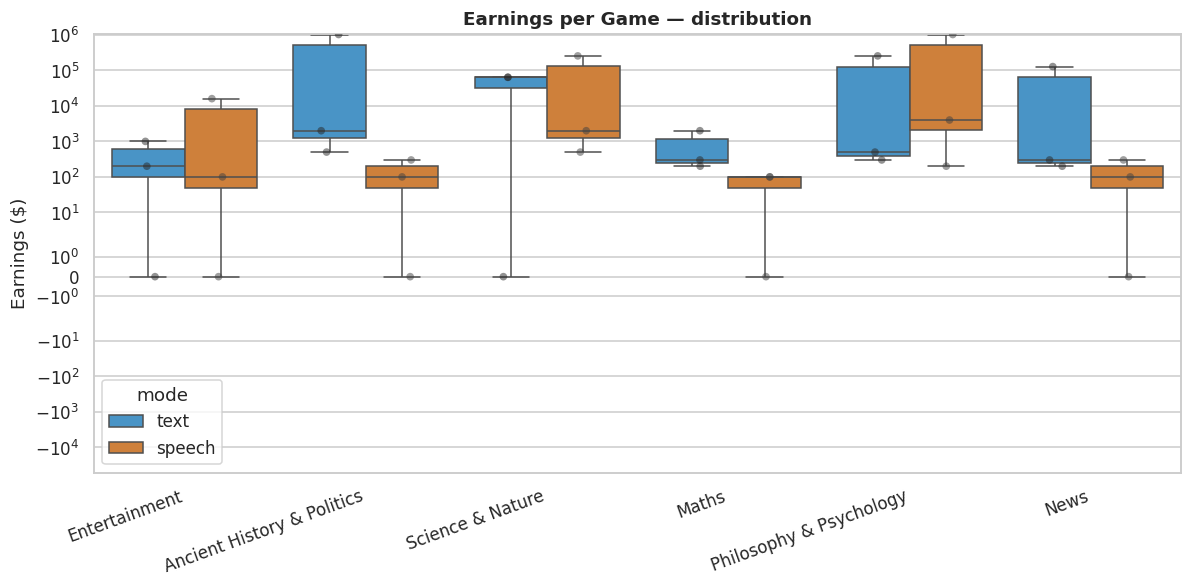

In [35]:
# Earnings boxplot per category, log y-axis if range is large.
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=g_all, x="category", y="earnings", hue="mode",
            palette={"text": "#3498db", "speech": "#e67e22"}, ax=ax)
sns.stripplot(data=g_all, x="category", y="earnings", hue="mode",
              dodge=True, alpha=0.5, palette="dark:.25", legend=False, ax=ax)
ax.set_title("Earnings per Game — distribution")
ax.set_xlabel("")
ax.set_ylabel("Earnings ($)")
if g_all["earnings"].max() > 5000:
    ax.set_yscale("symlog")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig("earnings_boxplot.png")
plt.show()


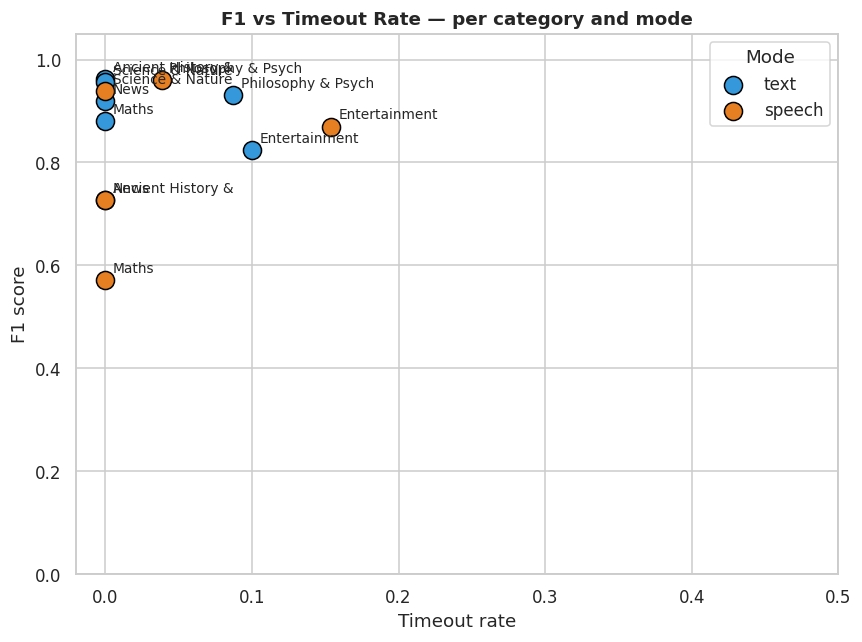

In [36]:
# Scatter — F1 vs timeout rate per (mode, category). Insight on tradeoffs.
fig, ax = plt.subplots(figsize=(8, 6))
for mode, color in [("text", "#3498db"), ("speech", "#e67e22")]:
    sub = ml_metrics[ml_metrics["mode"] == mode]
    ax.scatter(sub["timeout_rate"], sub["f1"], s=140, label=mode, color=color, edgecolor="black")
    for _, row in sub.iterrows():
        ax.annotate(row["category"][:18], (row["timeout_rate"], row["f1"]),
                    fontsize=9, xytext=(5, 5), textcoords="offset points")
ax.set_title("F1 vs Timeout Rate — per category and mode")
ax.set_xlabel("Timeout rate")
ax.set_ylabel("F1 score")
ax.set_xlim(-0.02, max(0.5, ml_metrics["timeout_rate"].max() + 0.05))
ax.set_ylim(0, 1.05)
ax.legend(title="Mode")
plt.tight_layout()
fig.savefig("f1_vs_timeout.png")
plt.show()


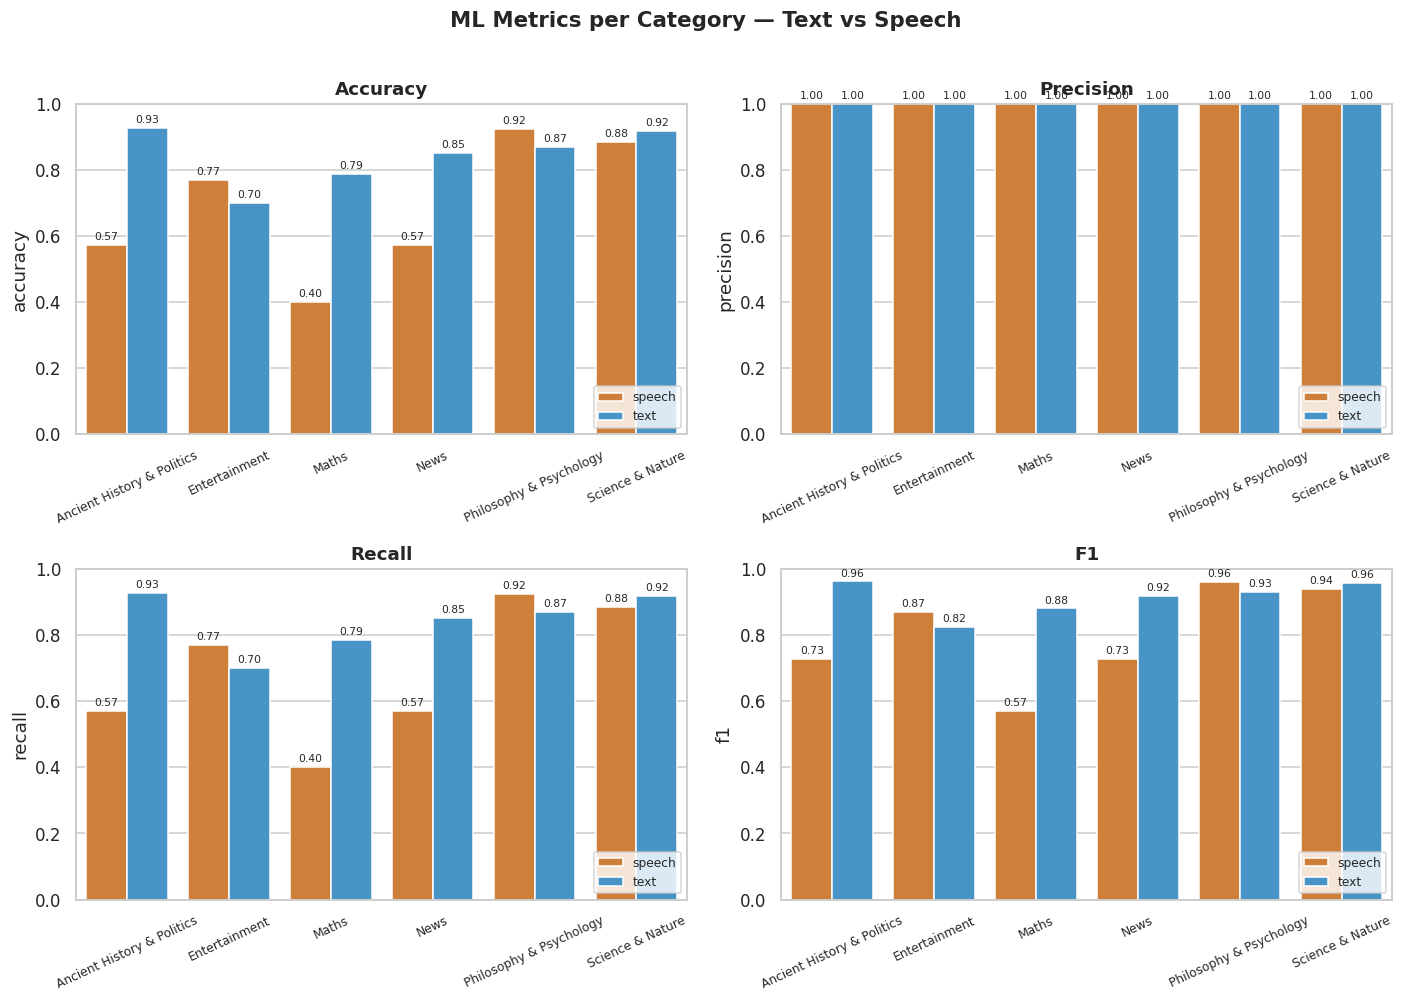

In [37]:
# Four-panel grid — accuracy / precision / recall / F1 per category.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metric_names = ["accuracy", "precision", "recall", "f1"]
for ax, m in zip(axes.flat, metric_names):
    sns.barplot(data=ml_metrics, x="category", y=m, hue="mode",
                palette={"text": "#3498db", "speech": "#e67e22"}, ax=ax)
    ax.set_title(m.capitalize())
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=25, labelsize=8)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", padding=2, fontsize=7)
    ax.legend(loc="lower right", fontsize=8)
plt.suptitle("ML Metrics per Category — Text vs Speech", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig("ml_metrics_grid.png")
plt.show()
